In [5]:
# ==== Linear Regression: visualize training via learning curves ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.metrics import r2_score, make_scorer
import time, os, json, joblib

# --- config (point to your combined CSV) ---
INPUT_CSV  = "/Users/alexpotter/AIoT-Lab/Datapreprocessing/Temp_combined_features.csv"
OUTPUT_DIR = "/Users/alexpotter/AIoT-Lab/Training/Temp_Adjust/Model"
HORIZON    = 1  # predict next-step indoor temp

REQUIRED_TIME_COL = "Timestamp"
REQUIRED_FEATURE_COLS = [
    "Indoor_Temperature_C",
    "Indoor_RH_Percent",
    "Outdoor_Temp_C",
    "Dewpoint_Temp_C",
    "Solar_Radiation_DNI_W_m2",
    "HVAC_Energy_usage_KWh",
]
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- load + target ---
df = pd.read_csv(INPUT_CSV)
ts = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce", infer_datetime_format=True)
if ts.notna().any():
    df = df.assign(_ts=ts).sort_values("_ts").drop(columns="_ts").reset_index(drop=True)

for c in REQUIRED_FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Indoor_Temperature_C"] = pd.to_numeric(df["Indoor_Temperature_C"], errors="coerce")
df["target_Indoor_Temperature_C_next"] = df["Indoor_Temperature_C"].shift(-HORIZON)
df = df.dropna(subset=["target_Indoor_Temperature_C_next"])

# add simple time features (keep raw timestamp out of model)
ts2 = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce")
df["Hour"] = ts2.dt.hour
df["DayOfWeek"] = ts2.dt.dayofweek
df["Month"] = ts2.dt.month
feature_cols = REQUIRED_FEATURE_COLS + ["Hour", "DayOfWeek", "Month"]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce").values
y = df["target_Indoor_Temperature_C_next"].astype(float).values


/var/folders/lw/kvyfkfps3wl6qfd2k99747yh0000gn/T/ipykernel_24124/1071852633.py:30: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  ts = pd.to_datetime(df[REQUIRED_TIME_COL], errors="coerce", infer_datetime_format=True)


Computing learning curves (this visualizes 'training process' for LR)...
Learning curve computed in 1.11s


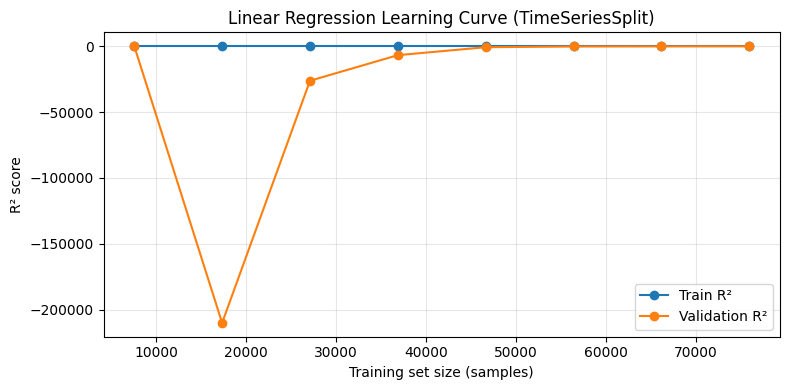

Linear Regression fit time: 0.140s
Final LR test metrics: {'MAE': 0.010820634256112542, 'RMSE': 0.01640060772020533, 'R2': 0.9998777705538507}


In [6]:
# --- pipeline ---
pipe = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])

# --- time series CV for realistic learning curves ---
tscv = TimeSeriesSplit(n_splits=5)
scorer = make_scorer(r2_score)

print("Computing learning curves (this visualizes 'training process' for LR)...")
t0 = time.time()
train_sizes, train_scores, val_scores, fit_times, _ = learning_curve(
    estimator=pipe,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    return_times=True,
    shuffle=False,
)
t1 = time.time()
print(f"Learning curve computed in {t1 - t0:.2f}s")

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# --- plot the learning curve ---
plt.figure(figsize=(8,4))
plt.plot(train_sizes, train_mean, marker="o", label="Train R²")
plt.plot(train_sizes, val_mean, marker="o", label="Validation R²")
plt.title("Linear Regression Learning Curve (TimeSeriesSplit)")
plt.xlabel("Training set size (samples)")
plt.ylabel("R² score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- final train/test for metrics (chronological 80/20) ---
n = len(X); split_idx = int(n*0.8)
X_train, y_train = X[:split_idx], y[:split_idx]
X_test,  y_test  = X[split_idx:], y[split_idx:]

t0 = time.time()
pipe.fit(X_train, y_train)
t1 = time.time()
print(f"Linear Regression fit time: {t1 - t0:.3f}s")

y_pred = pipe.predict(X_test)
metrics = {
    "MAE": float(np.mean(np.abs(y_test - y_pred))),
    "RMSE": float(np.sqrt(np.mean((y_test - y_pred)**2))),
    "R2": float(r2_score(y_test, y_pred)),
}
print("Final LR test metrics:", metrics)

# save
joblib.dump(pipe, os.path.join(OUTPUT_DIR, "linear_regression.joblib"))
with open(os.path.join(OUTPUT_DIR, "metrics_linear.json"), "w") as f:
    json.dump(metrics, f, indent=2)